In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [2]:
import gc
import os
import re
import sys
import time
import subprocess
from textwrap import fill

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from xgboost import XGBClassifier
import xgboost as xgb
from scipy import sparse
from scipy.stats import loguniform, randint
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score,recall_score,precision_score
from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 140
plt.rcParams['savefig.dpi'] = 140
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)
RANDOM_STATE = 42

print('Environment ready')
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Environment ready
/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [3]:
train_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample_submission_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')
print(f'Sample submission shape: {sample_submission_df.shape}')

Train shape: (198000, 15)
Test shape: (102000, 14)
Sample submission shape: (102000, 2)


## Notebook plan

This notebook follows a simple flow:

1. review the raw data
2. clean and standardize the inputs
3. build text and tabular features
4. train three models and compare them
5. blend predictions and prepare the final submission

In [4]:
train_df.select_dtypes(include='number').shape[1]

9

In [5]:
train_df.astype('object').shape[1]

15

In [6]:
train_df['disability'].unique()

array([False,  True])

In [7]:
missing_cols = train_df[['race','religion','gender','comment']].isnull().any()
print(missing_cols)

race        True
religion    True
gender      True
comment     True
dtype: bool


In [8]:
train_df['label'].value_counts()


label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

In [9]:
train_df['label'].value_counts(normalize=True) * 100


label
0    57.663131
2    31.535354
1     8.039394
3     2.762121
Name: proportion, dtype: float64

In [10]:
train_df['upvote'].median()


1.0

In [11]:
train_df.select_dtypes(include=['object']).shape[1]


5

In [12]:
train_df.select_dtypes(include=['int64', 'float64']).max()


post_id        129
emoticon_1      47
emoticon_2      11
emoticon_3      17
upvote         201
downvote       107
if_1          1860
if_2          1833
label            3
dtype: int64

In [13]:
train_df['if_2'].min()


3

In [14]:
def setup_feature_groups(train_df, test_df):
    for df in (train_df, test_df):
        df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')
        if df['created_date'].dt.tz is not None:
            df['created_date'] = df['created_date'].dt.tz_localize(None)

    text_col = 'comment'
    target_col = 'label'
    base_numeric = ['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2']
    identity_cols = ['race', 'religion', 'gender']
    cat_cols = identity_cols + ['disability']
    datetime_cols = ['created_date']
    return text_col, target_col, base_numeric, identity_cols, cat_cols, datetime_cols


text_col, target_col, base_numeric, identity_cols, cat_cols, datetime_cols = setup_feature_groups(train_df, test_df)

summary = train_df.isna().sum().sort_values(ascending=False).head(10).to_frame('missing')
summary['pct'] = (summary['missing'] / len(train_df)).round(3)
label_counts = train_df[target_col].value_counts().rename_axis('label').to_frame('count')
label_counts['pct'] = (label_counts['count'] / len(train_df)).round(3)

print('Feature groups ready')
print({'numeric': base_numeric, 'categorical': cat_cols, 'text': text_col, 'datetime': datetime_cols})
display(summary)
display(label_counts)
display(train_df[[text_col, target_col]].head())

Feature groups ready
{'numeric': ['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2'], 'categorical': ['race', 'religion', 'gender', 'disability'], 'text': 'comment', 'datetime': ['created_date']}


,missing,pct
gender,145423,0.734
race,145423,0.734
religion,145423,0.734
comment,1,0.000
created_date,0,0.000
post_id,0,0.000
emoticon_1,0,0.000
downvote,0,0.000
upvote,0,0.000
emoticon_3,0,0.000


,count,pct
label,,
0,114173,0.577
2,62440,0.315
1,15918,0.080
3,5469,0.028


,comment,label
0,She might be a bright spot for a party keou on...,2
1,"Under Alaska law, a non-tribal member is not b...",0
2,in the future please spare me your strawman dr...,2
3,"PS: That should have been ""rot"" instead of ""co...",2
4,"Today, the confederate flag...tomorrow, the na...",2


In [15]:
print({'numeric': base_numeric, 'categorical': cat_cols, 'text': text_col, 'datetime': datetime_cols})
display(train_df[[text_col, target_col]].head(3))

{'numeric': ['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2'], 'categorical': ['race', 'religion', 'gender', 'disability'], 'text': 'comment', 'datetime': ['created_date']}


,comment,label
0,She might be a bright spot for a party keou on...,2
1,"Under Alaska law, a non-tribal member is not b...",0
2,in the future please spare me your strawman dr...,2


## Data cleaning and feature setup

The next section trims extreme values, normalizes the identity columns, fixes date issues, and creates a cleaner text field for modeling.

In [16]:
def clip_text_words(series, q=0.99):
    counts = series.fillna('').str.split().str.len()
    cap = int(counts.quantile(q))
    return series.fillna('').apply(lambda x: ' '.join(str(x).split()[:cap])), cap


def normalize_identity_cols(df):
    for col in ['race', 'religion', 'gender']:
        if col in df.columns:
            df[col] = df[col].fillna('unknown')
    if 'disability' in df.columns:
        df['disability'] = df['disability'].fillna(False).astype(bool)


def fix_dates(df, col='created_date'):
    if col not in df.columns:
        return
    df[col] = pd.to_datetime(df[col], errors='coerce')
    if df[col].dt.tz is not None:
        df[col] = df[col].dt.tz_localize(None)
    df.loc[df[col] > pd.Timestamp('2026-02-28'), col] = pd.NaT
    df.loc[df[col] < pd.Timestamp('2010-01-01'), col] = pd.NaT


def remove_outliers_and_clean(df, is_train=True):
    df = df.copy()

    if is_train:
        up_99 = df['upvote'].quantile(0.99)
        down_99 = df['downvote'].quantile(0.99)
        keep = (df['upvote'] <= up_99) & (df['downvote'] <= down_99)
        df = df[keep].copy()
        df = df[df['comment'].fillna('').str.strip().str.len() >= 5].copy()

    df['upvote'] = df['upvote'].clip(upper=df['upvote'].quantile(0.95))
    df['downvote'] = df['downvote'].clip(upper=df['downvote'].quantile(0.95))
    df['comment'], _ = clip_text_words(df['comment'])

    for emo_col in ['emoticon_1', 'emoticon_2', 'emoticon_3']:
        if emo_col in df.columns:
            df[emo_col] = df[emo_col].clip(upper=df[emo_col].quantile(0.99))

    for if_col in ['if_1', 'if_2']:
        if if_col in df.columns:
            df[if_col] = df[if_col].clip(lower=0, upper=df[if_col].quantile(0.99))

    normalize_identity_cols(df)
    fix_dates(df)
    return df.reset_index(drop=True)


train_df = remove_outliers_and_clean(train_df, is_train=True)
test_df = remove_outliers_and_clean(test_df, is_train=False)
pd.DataFrame({'dataset': ['train', 'test'], 'rows': [len(train_df), len(test_df)]})

,dataset,rows
0,train,194501
1,test,102000


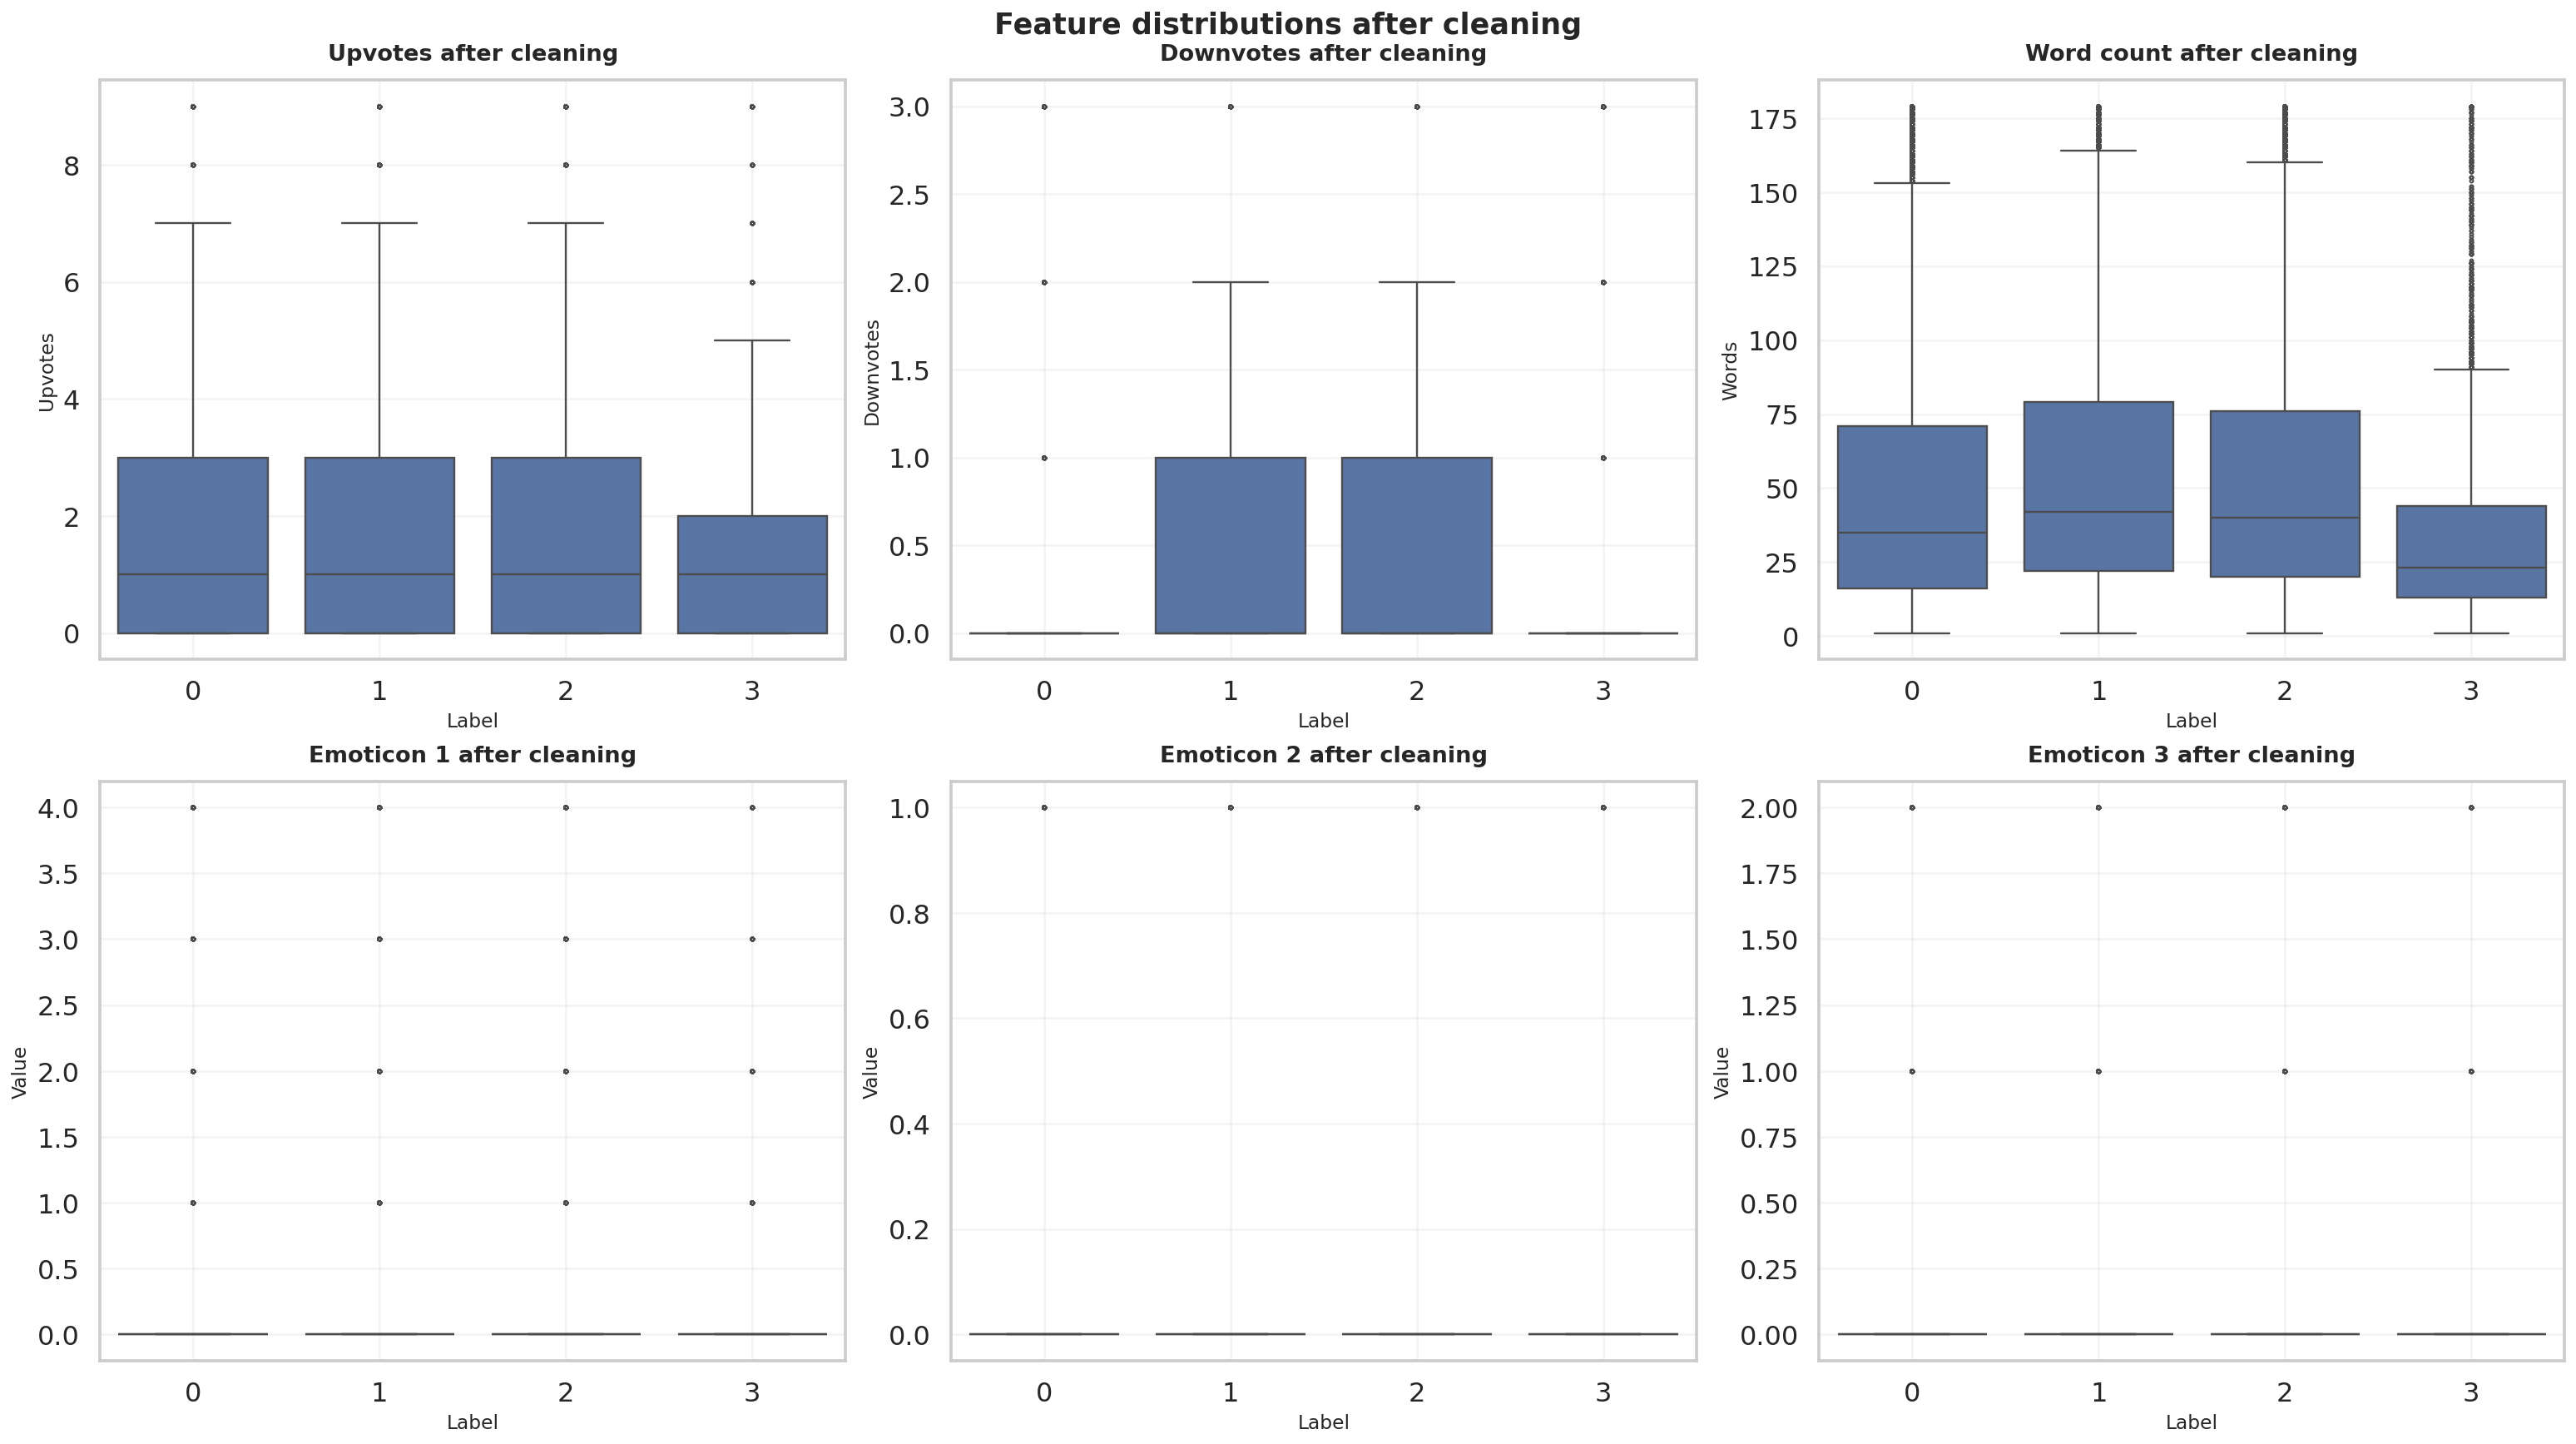

In [17]:
plot_df = train_df.copy()
plot_df['word_count_temp'] = plot_df['comment'].fillna('').str.split().str.len()

fig, axes = plt.subplots(2, 3, figsize=(22, 12), constrained_layout=True)
axes = axes.flatten()

plot_specs = [
    ('upvote', 'Upvotes after cleaning', 'Upvotes'),
    ('downvote', 'Downvotes after cleaning', 'Downvotes'),
    ('word_count_temp', 'Word count after cleaning', 'Words'),
    ('emoticon_1', 'Emoticon 1 after cleaning', 'Value'),
    ('emoticon_2', 'Emoticon 2 after cleaning', 'Value'),
    ('emoticon_3', 'Emoticon 3 after cleaning', 'Value'),
]

for ax, (column, title, ylabel) in zip(axes, plot_specs):
    sns.boxplot(data=plot_df, x='label', y=column, ax=ax, linewidth=1.2, fliersize=2)
    ax.set_title(title, pad=12, fontweight='bold')
    ax.set_xlabel('Label')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.2)

fig.suptitle('Feature distributions after cleaning', fontsize=18, fontweight='bold', y=1.02)
plt.show()

,feature,mean,median,std,max,q95
0,upvote,2.02,1.0,2.63,9,9.0
1,downvote,0.43,0.0,0.87,3,3.0
2,emoticon_1,0.24,0.0,0.69,4,2.0
3,emoticon_2,0.04,0.0,0.19,1,0.0
4,emoticon_3,0.10,0.0,0.35,2,1.0


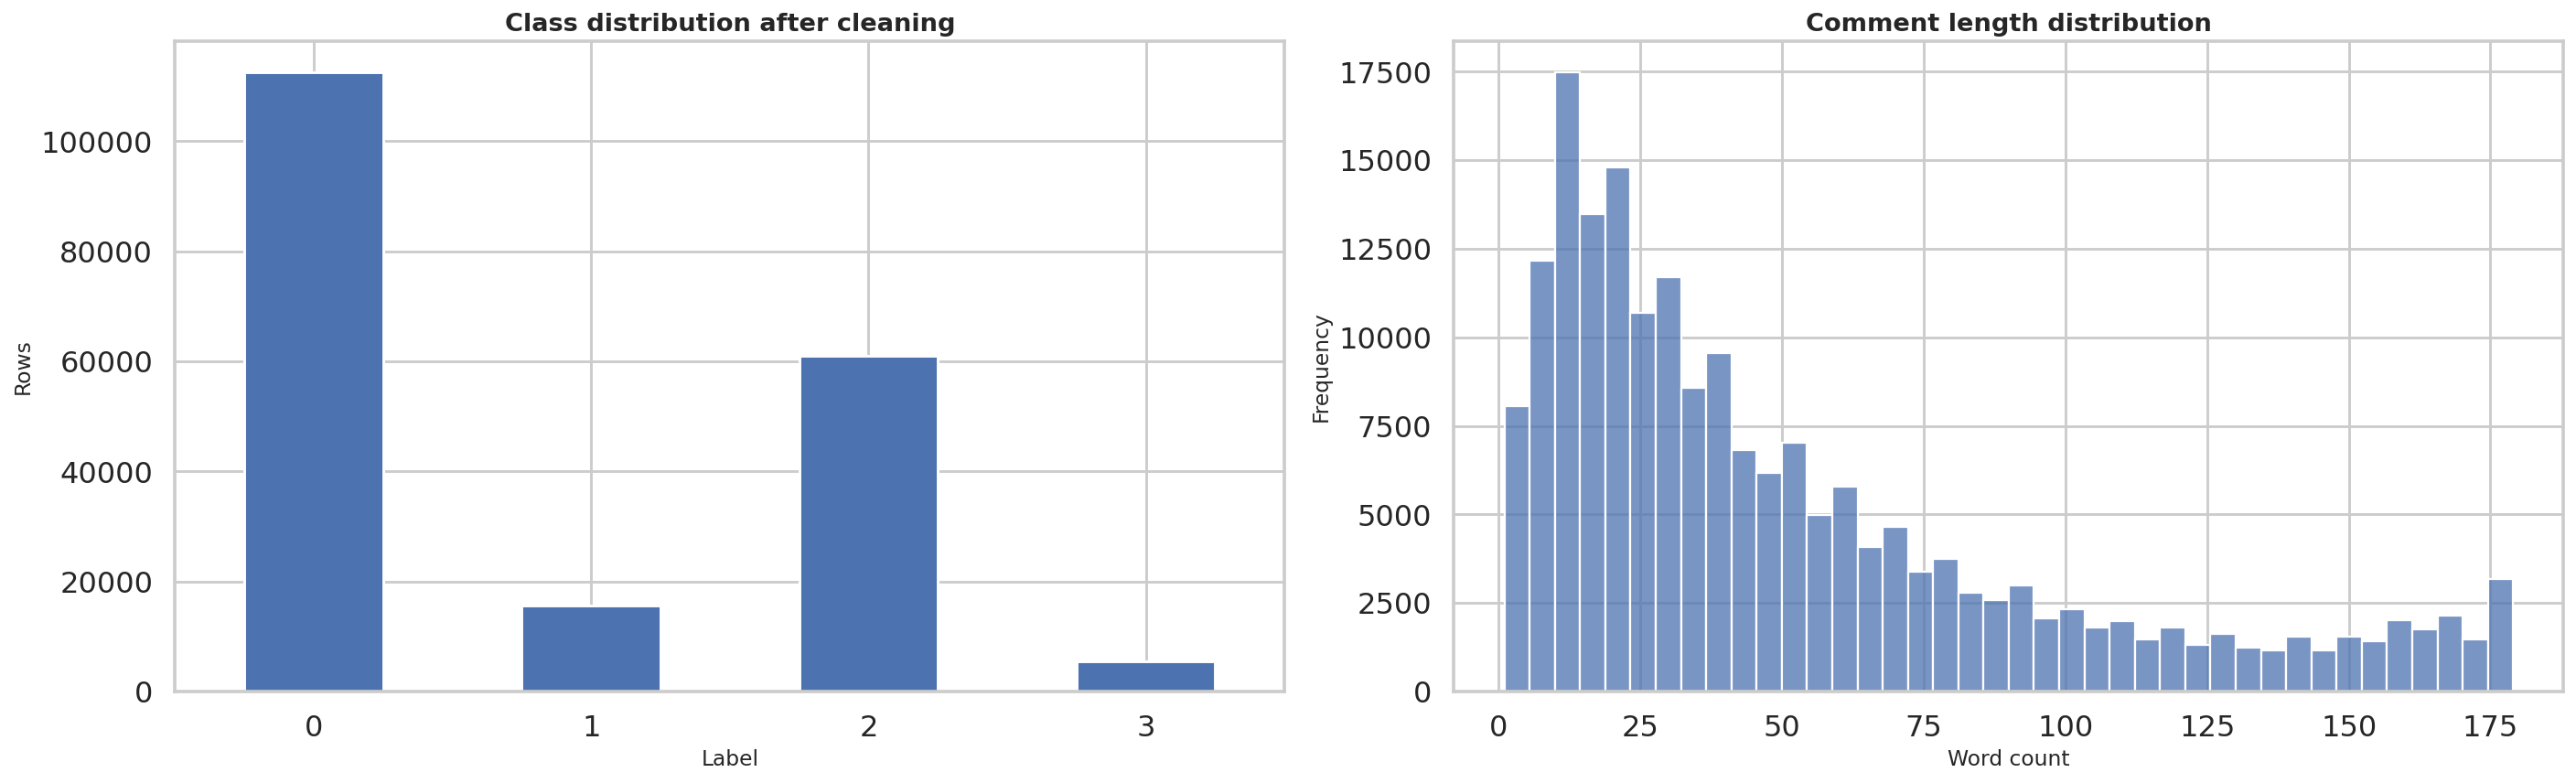

In [18]:
cleaned_stats = pd.DataFrame({
    'feature': ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3'],
    'mean': [train_df['upvote'].mean(), train_df['downvote'].mean(), train_df['emoticon_1'].mean(), train_df['emoticon_2'].mean(), train_df['emoticon_3'].mean()],
    'median': [train_df['upvote'].median(), train_df['downvote'].median(), train_df['emoticon_1'].median(), train_df['emoticon_2'].median(), train_df['emoticon_3'].median()],
    'std': [train_df['upvote'].std(), train_df['downvote'].std(), train_df['emoticon_1'].std(), train_df['emoticon_2'].std(), train_df['emoticon_3'].std()],
    'max': [train_df['upvote'].max(), train_df['downvote'].max(), train_df['emoticon_1'].max(), train_df['emoticon_2'].max(), train_df['emoticon_3'].max()],
    'q95': [train_df['upvote'].quantile(0.95), train_df['downvote'].quantile(0.95), train_df['emoticon_1'].quantile(0.95), train_df['emoticon_2'].quantile(0.95), train_df['emoticon_3'].quantile(0.95)]
})

display(cleaned_stats.round(2))

word_counts_clean = train_df['comment'].fillna('').str.split().str.len()
class_dist = train_df['label'].value_counts().sort_index()
missing_after = train_df.isnull().sum()
missing_after = missing_after[missing_after > 0].sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 6), constrained_layout=True)
class_dist.plot(kind='bar', ax=axes[0])
axes[0].set_title('Class distribution after cleaning', fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Rows')
axes[0].tick_params(axis='x', rotation=0)

sns.histplot(word_counts_clean, bins=40,ax=axes[1])
axes[1].set_title('Comment length distribution', fontweight='bold')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Frequency')

plt.show()

In [19]:
PATTERNS = {
    'url': re.compile(r'http\S+|www\S+', re.IGNORECASE),
    'email': re.compile(r'\S+@\S+'),
    'mention': re.compile(r'@\w+'),
    'hashtag': re.compile(r'#\w+'),
    'number': re.compile(r'\d+'),
    'symbol': re.compile(r'[^a-z0-9\s]')
}


def clean_comment(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = PATTERNS['url'].sub(' urltoken ', text)
    text = PATTERNS['email'].sub(' emailtoken ', text)
    text = PATTERNS['mention'].sub(' mentiontoken ', text)
    text = PATTERNS['hashtag'].sub(' hashtagtoken ', text)
    text = PATTERNS['number'].sub(' numtoken ', text)
    text = PATTERNS['symbol'].sub(' ', text)
    return ' '.join(text.split())


def add_features(df):
    df[text_col] = df[text_col].fillna('')
    df['comment_clean'] = df[text_col].apply(clean_comment)

    df['word_count'] = df['comment_clean'].str.split().str.len()
    df['char_count'] = df['comment_clean'].str.len()
    df['avg_word_len'] = df['char_count'] / (df['word_count'] + 1)
    df['bangs'] = df[text_col].str.count('!')
    df['questions'] = df[text_col].str.count(r'\?')
    df['capitals'] = df[text_col].str.count(r'[A-Z]')
    df['has_url'] = df[text_col].str.contains('http|www', regex=True).astype(int)

    df['engagement_ratio'] = (df['upvote'] + 1) / (df['downvote'] + 1)
    df['net_votes'] = df['upvote'] - df['downvote']
    df['total_votes'] = df['upvote'] + df['downvote']

    df['hour'] = df['created_date'].dt.hour.fillna(-1)
    df['day_of_week'] = df['created_date'].dt.dayofweek.fillna(-1)
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    for col in identity_cols:
        df[f'{col}_flag'] = df[col].fillna('none').ne('none').astype(int)
    df['disability_flag'] = df['disability'].fillna(False).astype(str).map({'True': 1, 'False': 0})
    df['identity_count'] = df[[f'{col}_flag' for col in identity_cols]].sum(axis=1) + df['disability_flag']

    df['emoticon_sum'] = df['emoticon_1'] + df['emoticon_2'] + df['emoticon_3']
    df['emoticon_diversity'] = (df[['emoticon_1', 'emoticon_2', 'emoticon_3']] > 0).sum(axis=1)


for frame in (train_df, test_df):
    add_features(frame)

extra_numeric = [
    'word_count', 'char_count', 'avg_word_len', 'bangs', 'questions', 'capitals', 'has_url',
    'engagement_ratio', 'net_votes', 'total_votes', 'hour', 'day_of_week', 'is_weekend',
    'emoticon_sum', 'emoticon_diversity', 'identity_count'
]
identity_flags = [f'{col}_flag' for col in identity_cols] + ['disability_flag']
numeric_features = base_numeric + extra_numeric + identity_flags
categorical_features = identity_cols + ['disability']
text_feature = 'comment_clean'

display(train_df[[text_col, text_feature, 'word_count', 'engagement_ratio']].head())

,comment,comment_clean,word_count,engagement_ratio
0,She might be a bright spot for a party keou on...,she might be a bright spot for a party keou on...,20,0.5
1,"Under Alaska law, a non-tribal member is not b...",under alaska law a non tribal member is not bo...,114,7.0
2,in the future please spare me your strawman dr...,in the future please spare me your strawman dr...,134,1.0
3,"PS: That should have been ""rot"" instead of ""co...",ps that should have been rot instead of corrup...,15,6.0
4,"Today, the confederate flag...tomorrow, the na...",today the confederate flag tomorrow the nazi f...,45,1.0


## Modeling strategy

The training block keeps the pipeline compact:

- TF-IDF for the cleaned text
- scaled numeric and encoded categorical inputs
- LightGBM for the main model
- LinearSVC on the full shared feature space
- AdaBoost on a smaller tabular feature set so it stays lightweight
- conservative thresholds for the final class decision

In [20]:
numeric_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', RobustScaler(with_centering=False))
])

categorical_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

categorical_pipe_dense = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [21]:
preprocess = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features),
    ('text', TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        dtype=np.float32
    ), text_feature)
], n_jobs=-1, sparse_threshold=1.0)

tabular_preprocess = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe_dense, categorical_features)
], n_jobs=-1, sparse_threshold=0.0)

In [22]:
train_cols = numeric_features + categorical_features + [text_feature]
train_features = train_df[train_cols].copy()
test_features = test_df[train_cols].copy()
y = train_df[target_col].astype(int).copy()

classes_ = np.sort(y.unique())
num_classes = len(classes_)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

fixed_class_weight = {0: 1.0, 1: 1.2, 2: 1.05, 3: 2.2}
blend_candidates = [
    (0.50, 0.30, 0.10, 0.10),
    (0.55, 0.25, 0.10, 0.10),
    (0.50, 0.25, 0.15, 0.10),
    (0.55, 0.20, 0.15, 0.10),
    (0.65, 0.25, 0.10, 0.00),
    ]
threshold_map = {0: 0.48, 1: 0.50, 2: 0.45, 3: 0.52}

performance_rows = []
best_models = {}

def log_config():
    info = f"Samples: {len(train_features):,} | Classes: {num_classes} | CV: 3-fold | Features: 4k TF-IDF + tabular"
    print(f"Configuration: {info}")

log_config()

Configuration: Samples: 194,501 | Classes: 4 | CV: 3-fold | Features: 4k TF-IDF + tabular


In [23]:
def prepare_lgb_matrix(X):
    if sparse.issparse(X):
        return X.tocsr().astype(np.float32)
    return np.asarray(X, dtype=np.float32)


def apply_per_class_thresholds(proba_matrix, thresholds):
    meets = proba_matrix >= thresholds
    override_scores = np.where(meets, proba_matrix, -1.0)
    override_choice = override_scores.argmax(axis=1)
    override_mask = override_scores.max(axis=1) >= 0
    preds = np.argmax(proba_matrix, axis=1)
    preds[override_mask] = override_choice[override_mask]
    return preds


def train_lgb_xgb_cross_val(train_features, test_features, y, cv, classes_, num_classes):
    oof_proba_lgb = np.zeros((len(train_features), num_classes), dtype=np.float32)
    oof_proba_xgb = np.zeros((len(train_features), num_classes), dtype=np.float32)
    test_proba_lgb_folds = []
    test_proba_xgb_folds = []
    fold_models_lgb = []
    fold_models_xgb = []

    for fold, (tr_idx, va_idx) in enumerate(cv.split(train_features, y), 1):
        X_tr = train_features.iloc[tr_idx]
        X_va = train_features.iloc[va_idx]
        X_te = test_features
        y_tr = y.iloc[tr_idx]
        y_va = y.iloc[va_idx]

        preprocess_fold = preprocess.fit(X_tr)

        X_tr_trans = preprocess_fold.transform(X_tr)
        X_va_trans = preprocess_fold.transform(X_va)
        X_te_trans = preprocess_fold.transform(X_te)

        X_tr_lgb = prepare_lgb_matrix(X_tr_trans)
        X_va_lgb = prepare_lgb_matrix(X_va_trans)
        X_te_lgb = prepare_lgb_matrix(X_te_trans)

        lgb_model = lgb.LGBMClassifier(
            objective='multiclass',
            num_class=num_classes,
            n_estimators=700,
            learning_rate=0.1,
            max_depth=6,
            num_leaves=31,
            max_bin=127,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=3,
            min_child_samples=40,
            class_weight=fixed_class_weight,
            random_state=42 + fold,
            n_jobs=-1,
            verbosity=-1,
            force_col_wise=True
        )

        lgb_model.fit(
            X_tr_lgb, y_tr,
            eval_set=[(X_va_lgb, y_va)],
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(period=-1)
            ]
        )

        oof_proba_lgb[va_idx] = lgb_model.predict_proba(X_va_lgb)
        test_proba_lgb_folds.append(lgb_model.predict_proba(X_te_lgb))
        fold_models_lgb.append(lgb_model)

        dtrain = xgb.DMatrix(X_tr_trans, label=y_tr.values)
        dval = xgb.DMatrix(X_va_trans, label=y_va.values)
        dtest = xgb.DMatrix(X_te_trans)

        xgb_params = {
            'objective': 'multi:softprob',
            'num_class': num_classes,
            'max_depth': 7,
            'learning_rate': 0.08,
            'subsample': 0.7,
            'colsample_bytree': 0.7,
            'tree_method': 'hist',
            'gamma': 0.1,
            'reg_lambda': 3.0,
            'reg_alpha': 0.5,
            'min_child_weight': 2,
            'eval_metric': 'mlogloss',
            'seed': 42 + fold,
            'nthread': -1
        }

        xgb_model = xgb.train(
            xgb_params,
            dtrain,
            num_boost_round=200,
            evals=[(dtrain, 'train'), (dval, 'eval')],
            early_stopping_rounds=40,
            verbose_eval=False
        )

        oof_proba_xgb[va_idx] = xgb_model.predict(dval)
        test_proba_xgb_folds.append(xgb_model.predict(dtest))
        fold_models_xgb.append(xgb_model)

        gc.collect()

    return (
        oof_proba_lgb,
        oof_proba_xgb,
        np.mean(test_proba_lgb_folds, axis=0),
        np.mean(test_proba_xgb_folds, axis=0),
        fold_models_lgb,
        fold_models_xgb
    )


oof_proba_lgb, oof_proba_xgb, test_proba_lgb_mean, test_proba_xgb_mean, fold_models_lgb, fold_models_xgb = train_lgb_xgb_cross_val(
    train_features, test_features, y, cv, classes_, num_classes
)

oof_pred_lgb = oof_proba_lgb.argmax(axis=1)
oof_pred_xgb = oof_proba_xgb.argmax(axis=1)

oof_f1_lgb = f1_score(y, oof_pred_lgb, average='macro')
oof_f1_xgb = f1_score(y, oof_pred_xgb, average='macro')

performance_rows.append({
    'model': 'LightGBM 3-fold OOF',
    'accuracy': round(accuracy_score(y, oof_pred_lgb), 4),
    'f1_macro': round(oof_f1_lgb, 4),
    'train_time_sec': None
})

performance_rows.append({
    'model': 'XGBoost 3-fold OOF',
    'accuracy': round(accuracy_score(y, oof_pred_xgb), 4),
    'f1_macro': round(oof_f1_xgb, 4),
    'train_time_sec': None
})

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [24]:
preprocess_rs = preprocess.fit(train_features)
X_rs = prepare_lgb_matrix(preprocess_rs.transform(train_features))

rs_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lgb_param_dist = {
    'learning_rate': [0.05, 0.08, 0.1],
    'num_leaves': [31, 63],
    'max_depth': [5, 6, 7],
    'reg_lambda': [1, 3, 5],
    'subsample': [0.7, 0.8],
    'min_child_samples': [30, 40, 50],
}

lgb_base = lgb.LGBMClassifier(
    objective='multiclass', num_class=num_classes, n_estimators=300,
    max_bin=127, colsample_bytree=0.8, class_weight=fixed_class_weight,
    random_state=42, n_jobs=-1, verbosity=-1, force_col_wise=True
)

lgb_rs = RandomizedSearchCV(
    lgb_base, lgb_param_dist, n_iter=5, cv=rs_cv,
    scoring='f1_macro', n_jobs=-1, random_state=42, refit=False
)
lgb_rs.fit(X_rs, y)
best_lgb_params = lgb_rs.best_params_
print('Best LGB params:', best_lgb_params)
print('Best LGB CV F1:', round(lgb_rs.best_score_, 4))

xgb_param_dist = {
    'learning_rate': [0.05, 0.08, 0.1],
    'max_depth': [5, 6, 7],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'gamma': [0.0, 0.1, 0.2],
    'reg_lambda': [1.0, 3.0, 5.0],
    'min_child_weight': [1, 2, 3],
}

xgb_base = XGBClassifier(
    objective='multi:softprob', num_class=num_classes, n_estimators=200,
    tree_method='hist', eval_metric='mlogloss',
    use_label_encoder=False, random_state=42, n_jobs=-1, verbosity=0
)

xgb_rs = RandomizedSearchCV(
    xgb_base, xgb_param_dist, n_iter=5, cv=rs_cv,
    scoring='f1_macro', n_jobs=-1, random_state=42, refit=False
)
xgb_rs.fit(X_rs, y)
best_xgb_params = xgb_rs.best_params_
print('Best XGB params:', best_xgb_params)
print('Best XGB CV F1:', round(xgb_rs.best_score_, 4))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warning

Best LGB params: {'subsample': 0.7, 'reg_lambda': 1, 'num_leaves': 31, 'min_child_samples': 30, 'max_depth': 7, 'learning_rate': 0.08}
Best LGB CV F1: 0.7961
Best XGB params: {'subsample': 0.7, 'reg_lambda': 1.0, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.08, 'gamma': 0.0, 'colsample_bytree': 0.7}
Best XGB CV F1: 0.7692


In [25]:
def train_lgb_xgb_cross_val_tuned(train_features, test_features, y, cv, classes_, num_classes, lgb_params, xgb_params):
    oof_proba_lgb = np.zeros((len(train_features), num_classes), dtype=np.float32)
    oof_proba_xgb = np.zeros((len(train_features), num_classes), dtype=np.float32)
    test_proba_lgb_folds, test_proba_xgb_folds = [], []
    fold_models_lgb, fold_models_xgb = [], []

    for fold, (tr_idx, va_idx) in enumerate(cv.split(train_features, y), 1):
        X_tr = train_features.iloc[tr_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        X_va, X_te = train_features.iloc[va_idx], test_features

        preprocess_fold = preprocess.fit(X_tr)
        X_tr_lgb = prepare_lgb_matrix(preprocess_fold.transform(X_tr))
        X_va_lgb = prepare_lgb_matrix(preprocess_fold.transform(X_va))
        X_te_lgb = prepare_lgb_matrix(preprocess_fold.transform(X_te))

        lgb_fold = lgb.LGBMClassifier(
            objective='multiclass', num_class=num_classes, n_estimators=700,
            max_bin=127, colsample_bytree=lgb_params.get('colsample_bytree', 0.8),
            class_weight=fixed_class_weight,
            learning_rate=lgb_params.get('learning_rate', 0.1),
            max_depth=lgb_params.get('max_depth', 6),
            num_leaves=lgb_params.get('num_leaves', 31),
            subsample=lgb_params.get('subsample', 0.8),
            reg_lambda=lgb_params.get('reg_lambda', 3),
            min_child_samples=lgb_params.get('min_child_samples', 40),
            random_state=42 + fold, n_jobs=-1, verbosity=-1, force_col_wise=True
        )
        lgb_fold.fit(X_tr_lgb, y_tr, eval_set=[(X_va_lgb, y_va)],
                     callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)])

        oof_proba_lgb[va_idx] = lgb_fold.predict_proba(X_va_lgb)
        test_proba_lgb_folds.append(lgb_fold.predict_proba(X_te_lgb))
        fold_models_lgb.append(lgb_fold)

        dtrain_xgb = xgb.DMatrix(X_tr_lgb, label=y_tr.values, nthread=-1)
        dval_xgb   = xgb.DMatrix(X_va_lgb, label=y_va.values, nthread=-1)
        dtest_xgb  = xgb.DMatrix(X_te_lgb, nthread=-1)

        xgb_native_params = {
            'objective': 'multi:softprob', 'num_class': num_classes,
            'max_depth': xgb_params.get('max_depth', 7),
            'learning_rate': xgb_params.get('learning_rate', 0.08),
            'subsample': xgb_params.get('subsample', 0.7),
            'colsample_bytree': xgb_params.get('colsample_bytree', 0.7),
            'tree_method': 'hist',
            'gamma': xgb_params.get('gamma', 0.1),
            'reg_lambda': xgb_params.get('reg_lambda', 3.0),
            'reg_alpha': 0.5,
            'min_child_weight': xgb_params.get('min_child_weight', 2),
            'nthread': -1, 'eval_metric': 'mlogloss', 'seed': 42 + fold
        }
        xgb_fold = xgb.train(xgb_native_params, dtrain_xgb, num_boost_round=200,
                             evals=[(dtrain_xgb, 'train'), (dval_xgb, 'eval')],
                             early_stopping_rounds=40, verbose_eval=False)

        oof_proba_xgb[va_idx] = xgb_fold.predict(dval_xgb)
        test_proba_xgb_folds.append(xgb_fold.predict(dtest_xgb))
        fold_models_xgb.append(xgb_fold)

        gc.collect()

    return (oof_proba_lgb, oof_proba_xgb, np.mean(test_proba_lgb_folds, axis=0),
            np.mean(test_proba_xgb_folds, axis=0), fold_models_lgb, fold_models_xgb)


oof_proba_lgb, oof_proba_xgb, test_proba_lgb_mean, test_proba_xgb_mean, fold_models_lgb, fold_models_xgb = \
    train_lgb_xgb_cross_val_tuned(train_features, test_features, y, cv, classes_, num_classes, best_lgb_params, best_xgb_params)

oof_pred_lgb = oof_proba_lgb.argmax(axis=1)
oof_f1_lgb = f1_score(y, oof_pred_lgb, average='macro')
oof_pred_xgb = oof_proba_xgb.argmax(axis=1)
oof_f1_xgb = f1_score(y, oof_pred_xgb, average='macro')

performance_rows.append({'model': 'LightGBM Tuned 3-fold OOF', 'accuracy': round(accuracy_score(y, oof_pred_lgb), 4), 'f1_macro': round(oof_f1_lgb, 4), 'train_time_sec': None})
performance_rows.append({'model': 'XGBoost Tuned 3-fold OOF', 'accuracy': round(accuracy_score(y, oof_pred_xgb), 4), 'f1_macro': round(oof_f1_xgb, 4), 'train_time_sec': None})
print('Tuned LGB OOF F1:', round(oof_f1_lgb, 4))
print('Tuned XGB OOF F1:', round(oof_f1_xgb, 4))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Tuned LGB OOF F1: 0.8002
Tuned XGB OOF F1: 0.7706


In [26]:
# Shared preprocessing for SVC + LR 
preprocess_shared = preprocess.fit(train_features)
X_train_shared = preprocess_shared.transform(train_features).astype(np.float32)
X_test_shared  = preprocess_shared.transform(test_features).astype(np.float32)

# Tabular preprocessing for AdaBoost 
tabular_preprocess_shared = tabular_preprocess.fit(train_features)
X_train_ada = np.asarray(tabular_preprocess_shared.transform(train_features), dtype=np.float32)
X_test_ada  = np.asarray(tabular_preprocess_shared.transform(test_features),  dtype=np.float32)

In [27]:
# SVC
svc_base  = LinearSVC(
    class_weight='balanced', max_iter=2500, tol=1e-3,
    random_state=42, dual='auto', loss='squared_hinge'
)
svc_model = CalibratedClassifierCV(svc_base, cv=2, method='sigmoid')
svc_model.fit(X_train_shared, y)
oof_proba_svc      = svc_model.predict_proba(X_train_shared)
test_proba_svc_mean = svc_model.predict_proba(X_test_shared)

oof_pred_svc = oof_proba_svc.argmax(axis=1)
oof_f1_svc   = f1_score(y, oof_pred_svc, average='macro')
performance_rows.append({
    'model': 'LinearSVC single pass',
    'accuracy': round(accuracy_score(y, oof_pred_svc), 4),
    'f1_macro': round(oof_f1_svc, 4),
    'train_time_sec': None
})

In [28]:
#logistic-regression
sample_weights = compute_sample_weight('balanced', y)

lr_model = LogisticRegression(
    max_iter=3500, solver='lbfgs', class_weight='balanced',
    random_state=42, n_jobs=-1, multi_class='multinomial'
)

lr_model.fit(X_train_shared, y, sample_weight=sample_weights)
oof_proba_lr      = lr_model.predict_proba(X_train_shared)
test_proba_lr_mean = lr_model.predict_proba(X_test_shared)

oof_pred_lr = oof_proba_lr.argmax(axis=1)
oof_f1_lr   = f1_score(y, oof_pred_lr, average='macro')
performance_rows.append({
    'model': 'LogisticRegression',
    'accuracy': round(accuracy_score(y, oof_pred_lr), 4),
    'f1_macro': round(oof_f1_lr, 4),
    'train_time_sec': None
})

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [29]:
# Adaboost
ada_model = AdaBoostClassifier(
    n_estimators=60, learning_rate=0.6, random_state=42
)

ada_model.fit(X_train_ada, y)
oof_proba_ada = ada_model.predict_proba(X_train_ada)
test_proba_ada = ada_model.predict_proba(X_test_ada)

oof_pred_ada = oof_proba_ada.argmax(axis=1)
oof_f1_ada   = f1_score(y, oof_pred_ada, average='macro')
performance_rows.append({
    'model': 'AdaBoost single pass',
    'accuracy': round(accuracy_score(y, oof_pred_ada), 4),
    'f1_macro': round(oof_f1_ada, 4),
    'train_time_sec': None
})

In [30]:
best_models.update({
    'LinearSVC':         svc_model,
    'LogisticRegression': lr_model,
    'AdaBoost':          ada_model
})

In [31]:
def optimize_per_class_thresholds(proba_matrix, y_true, n_trials=50):
    best_thresholds = {}
    best_f1 = 0
    
    for cls in range(num_classes):
        cls_mask = y_true == cls
        proba_cls = proba_matrix[:, cls]
        
        if cls_mask.sum() < 5:
            best_thresholds[cls] = 0.5
            continue
            
        f1_scores = []
        thresholds_to_try = np.linspace(0.2, 0.8, n_trials)
        
        for thresh in thresholds_to_try:
            preds = apply_per_class_thresholds(proba_matrix, np.array([thresh if i == cls else threshold_map.get(i, 0.5) for i in range(num_classes)], dtype=np.float32))
            f1 = f1_score(y_true, preds, average='macro', zero_division=0)
            f1_scores.append(f1)
        
        if f1_scores:
            best_idx = np.argmax(f1_scores)
            best_thresholds[cls] = thresholds_to_try[best_idx]
    
    return np.array([best_thresholds.get(i, threshold_map.get(i, 0.5)) for i in range(num_classes)], dtype=np.float32)

In [32]:
optimized_thresholds = optimize_per_class_thresholds(oof_proba_lgb, y, n_trials=40)

tuned_preds_lgb = apply_per_class_thresholds(oof_proba_lgb, optimized_thresholds)
tuned_acc_lgb = accuracy_score(y, tuned_preds_lgb)
tuned_f1_lgb = f1_score(y, tuned_preds_lgb, average='macro')

performance_rows.append({
    'model': 'LightGBM with optimized thresholds',
    'accuracy': round(tuned_acc_lgb, 4),
    'f1_macro': round(tuned_f1_lgb, 4),
    'train_time_sec': None
})


In [33]:
blend_candidates_extended = [
    (0.40, 0.20, 0.20, 0.10, 0.10),
    (0.45, 0.20, 0.20, 0.10, 0.05),
    (0.50, 0.25, 0.15, 0.05, 0.05),
    (0.55, 0.20, 0.15, 0.05, 0.05),
    (0.60, 0.15, 0.15, 0.05, 0.05),
    (0.50, 0.20, 0.15, 0.10, 0.05),
]
blend_results = []
for alpha_lgb, alpha_lr, alpha_xgb, alpha_svc, alpha_ada in blend_candidates_extended:
    blended_oof_proba = (
        alpha_lgb * oof_proba_lgb +
        alpha_lr * oof_proba_lr +
        alpha_xgb * oof_proba_xgb +
        alpha_svc * oof_proba_svc +
        alpha_ada * oof_proba_ada
    )
    blended_oof_pred = apply_per_class_thresholds(blended_oof_proba, optimized_thresholds)
    blended_f1 = f1_score(y, blended_oof_pred, average='macro')
    blend_results.append((alpha_lgb, alpha_lr, alpha_xgb, alpha_svc, alpha_ada, blended_f1))

blend_results = sorted(blend_results, key=lambda x: x[5], reverse=True)
BEST_ALPHA_LGB, BEST_ALPHA_LR, BEST_ALPHA_XGB, BEST_ALPHA_SVC, BEST_ALPHA_ADA, BEST_BLEND_F1 = blend_results[0]

best_oof_blend_proba = (
    BEST_ALPHA_LGB * oof_proba_lgb +
    BEST_ALPHA_LR * oof_proba_lr +
    BEST_ALPHA_XGB * oof_proba_xgb +
    BEST_ALPHA_SVC * oof_proba_svc +
    BEST_ALPHA_ADA * oof_proba_ada
)
best_oof_blend_pred = apply_per_class_thresholds(best_oof_blend_proba, optimized_thresholds)

performance_rows.append({
    'model': f'5-way blend (LGB {BEST_ALPHA_LGB:.2f}, LR {BEST_ALPHA_LR:.2f}, XGB {BEST_ALPHA_XGB:.2f}, SVC {BEST_ALPHA_SVC:.2f}, ADA {BEST_ALPHA_ADA:.2f})',
    'accuracy': round(accuracy_score(y, best_oof_blend_pred), 4),
    'f1_macro': round(f1_score(y, best_oof_blend_pred, average='macro'), 4),
    'train_time_sec': None
})

In [34]:
test_blend_proba_cv = (
    BEST_ALPHA_LGB * test_proba_lgb_mean +
    BEST_ALPHA_LR * test_proba_lr_mean +
    BEST_ALPHA_XGB * test_proba_xgb_mean +
    BEST_ALPHA_SVC * test_proba_svc_mean +
    BEST_ALPHA_ADA * test_proba_ada
)
test_pred_blend_cv = apply_per_class_thresholds(test_blend_proba_cv, optimized_thresholds)

In [35]:
performance_df = pd.DataFrame(performance_rows)
if performance_df.empty:
    raise ValueError('No performance metrics were collected during training.')

performance_df = performance_df.sort_values(by='f1_macro', ascending=False).reset_index(drop=True)

if 'train_time_sec' in performance_df.columns:
    max_time = performance_df['train_time_sec'].max() or 0.0
    performance_df['train_time_sec_filled'] = performance_df['train_time_sec'].fillna(max_time)
    performance_df['speed_rank'] = performance_df['train_time_sec_filled'].rank()
else:
    performance_df['speed_rank'] = range(1, len(performance_df) + 1)

performance_df['accuracy_rank'] = performance_df['accuracy'].rank(ascending=False)
performance_df['f1_rank'] = performance_df['f1_macro'].rank(ascending=False)
performance_df['overall_score'] = performance_df['f1_rank'] * 2 + performance_df['accuracy_rank']

summary_cols = ['model', 'accuracy', 'f1_macro', 'train_time_sec', 'overall_score']
display(performance_df[summary_cols])

/tmp/ipykernel_17/2686699433.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  performance_df['train_time_sec_filled'] = performance_df['train_time_sec'].fillna(max_time)


,model,accuracy,f1_macro,train_time_sec,overall_score
0,"5-way blend (LGB 0.40, LR 0.20, XGB 0.20, SVC ...",0.9109,0.8183,None,3.0
1,LightGBM with optimized thresholds,0.9091,0.8025,None,6.5
2,LightGBM 3-fold OOF,0.9090,0.8007,None,10.0
3,LightGBM Tuned 3-fold OOF,0.9091,0.8002,None,10.5
4,LinearSVC single pass,0.8924,0.7781,None,17.0
5,XGBoost Tuned 3-fold OOF,0.9046,0.7706,None,17.0
6,XGBoost 3-fold OOF,0.9042,0.7690,None,20.0
7,LogisticRegression,0.8253,0.6979,None,25.0
8,AdaBoost single pass,0.8632,0.5600,None,26.0


/tmp/ipykernel_17/798749053.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, y='model', x='f1_macro', ax=axes[0], palette='Blues_r')


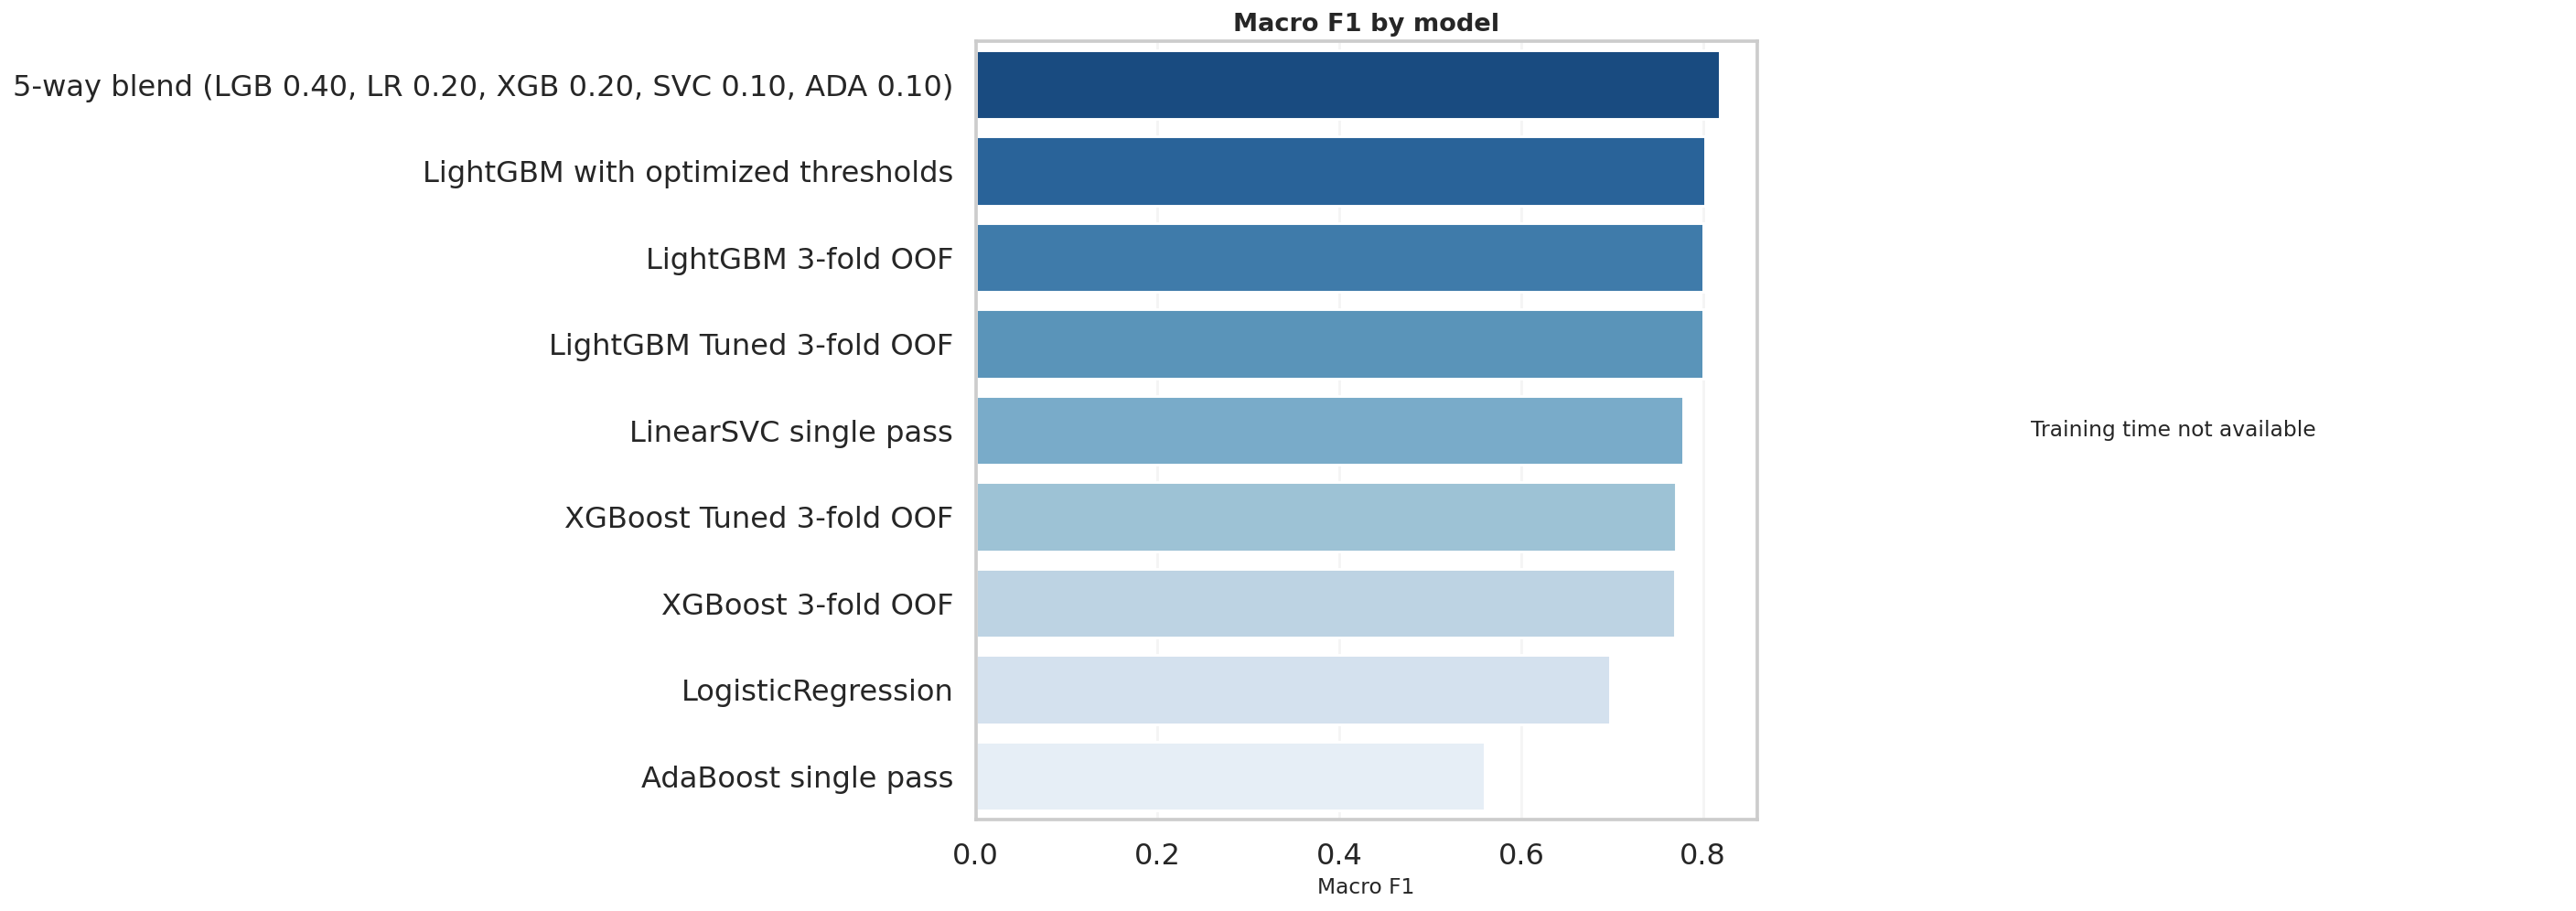

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7), constrained_layout=True)
plot_df = performance_df.copy()

sns.barplot(data=plot_df, y='model', x='f1_macro', ax=axes[0], palette='Blues_r')
axes[0].set_title('Macro F1 by model', fontweight='bold')
axes[0].set_xlabel('Macro F1')
axes[0].set_ylabel('')
axes[0].grid(axis='x', alpha=0.2)

speed_df = plot_df.dropna(subset=['train_time_sec'])
if speed_df.empty:
    axes[1].text(0.5, 0.5, 'Training time not available', ha='center', va='center', fontsize=12)
    axes[1].set_axis_off()
else:
    sns.barplot(data=speed_df, y='model', x='train_time_sec', ax=axes[1], palette='Greens_r')
    axes[1].set_title('Training time by model', fontweight='bold')
    axes[1].set_xlabel('Seconds')
    axes[1].set_ylabel('')
    axes[1].grid(axis='x', alpha=0.2)

plt.show()

In [37]:
models_eval = [
    ('LightGBM', oof_pred_lgb, oof_proba_lgb),
    ('XGBoost', oof_pred_xgb, oof_proba_xgb),
    ('LinearSVC', oof_pred_svc, oof_proba_svc),
    ('LogisticRegression', oof_pred_lr, oof_proba_lr),
    ('AdaBoost', oof_pred_ada, oof_proba_ada),
    ('5-way Blend', best_oof_blend_pred, best_oof_blend_proba),
]

In [38]:
analysis_data = []
for model_name, preds, probas in models_eval:
    acc = accuracy_score(y, preds)
    f1_macro = f1_score(y, preds, average='macro')
    
    class_metrics = []
    recalls_all = recall_score(y, preds, labels=classes_, average=None, zero_division=0)
    precisions_all = precision_score(y, preds, labels=classes_, average=None, zero_division=0)
    f1_all = f1_score(y, preds, labels=classes_, average=None, zero_division=0)
    
    for cls_idx, cls in enumerate(classes_):
        recall = recalls_all[cls_idx]
        precision = precisions_all[cls_idx]
        f1_cls = f1_all[cls_idx]
        support = (y == cls).sum()
        
        class_metrics.append({
            'Model': model_name,
            'Class': int(cls),
            'Precision': round(precision, 3),
            'Recall': round(recall, 3),
            'F1': round(f1_cls, 3),
            'Support': int(support)
        })
        
        analysis_data.append({
            'Model': model_name,
            'Accuracy': round(acc, 4),
            'Macro F1': round(f1_macro, 4),
            'Class': int(cls),
            'Recall': round(recall, 3),
            'Precision': round(precision, 3),
            'F1-Class': round(f1_cls, 3),
            'Support': int(support)
        })

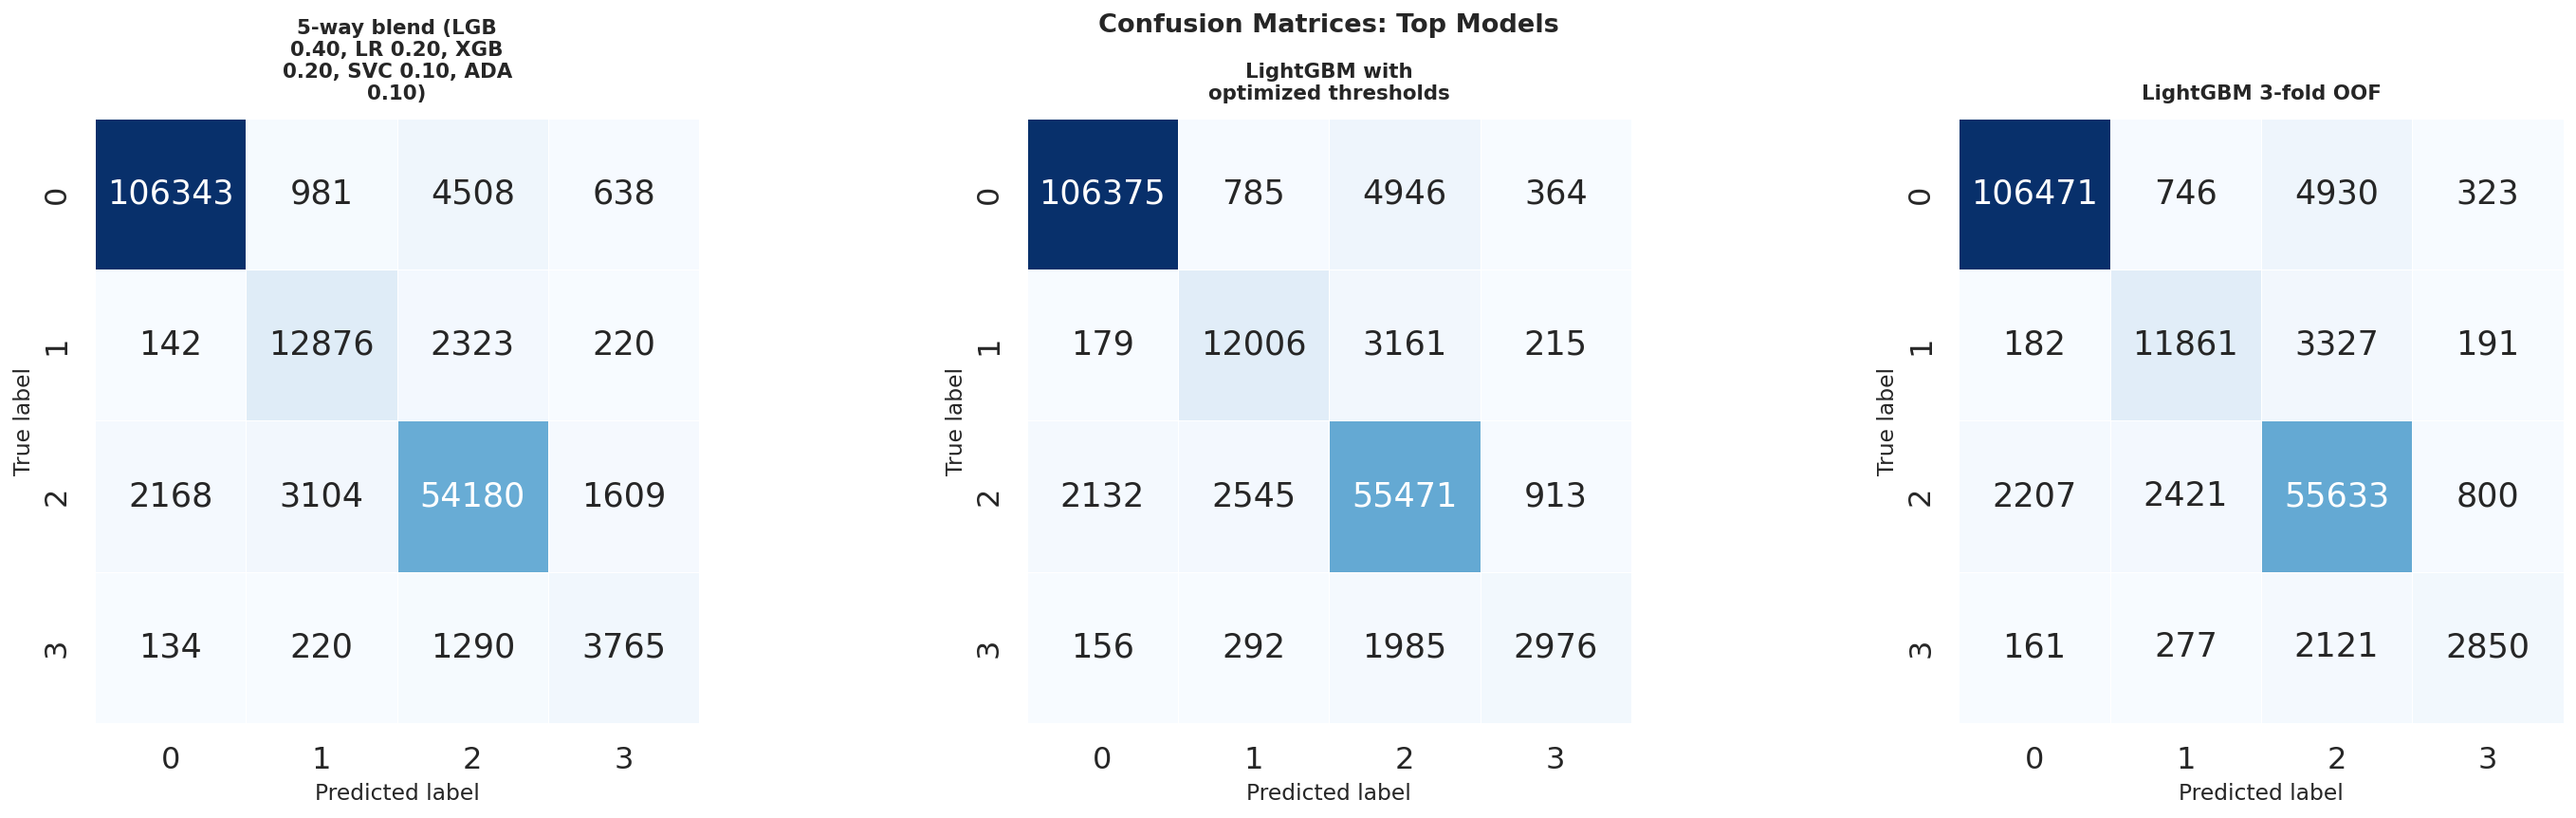

In [39]:
def get_validation_predictions(model_name):
    name = model_name.lower()
    if '5-way' in name:
        return best_oof_blend_pred
    if 'optimized' in name:
        return tuned_preds_lgb
    if 'xgboost' in name:
        return oof_pred_xgb
    if 'linearsvc' in name:
        return oof_pred_svc
    if 'adaboost' in name:
        return oof_pred_ada
    if 'logistic' in name:
        return oof_pred_lr
    return oof_pred_lgb


available_models = performance_df['model'].tolist()
selected_models = [m for m in available_models if any(x in m.lower() for x in ['5-way', 'optimized', '3-fold'])][:3]

if len(selected_models) == 0:
    selected_models = available_models[:3]

num_cols = min(len(selected_models), 3)
fig, axes = plt.subplots(1, num_cols, figsize=(7 * num_cols, 6), constrained_layout=True)
if num_cols == 1:
    axes = [axes]


for ax, model_name in zip(axes, selected_models):
    preds = get_validation_predictions(model_name)
    cm = confusion_matrix(y, preds)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        square=True,
        linewidths=0.5,
        linecolor='white',
        ax=ax
    )
    ax.set_title(fill(model_name, width=20), fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')

fig.suptitle('Confusion Matrices: Top Models', fontsize=14, fontweight='bold', y=1.00)
plt.show()

In [40]:
comparison_data = []
lgb_recalls = recall_score(y, oof_pred_lgb, labels=classes_, average=None, zero_division=0)
blend_recalls = recall_score(y, best_oof_blend_pred, labels=classes_, average=None, zero_division=0)
lgb_f1s = f1_score(y, oof_pred_lgb, labels=classes_, average=None, zero_division=0)
blend_f1s = f1_score(y, best_oof_blend_pred, labels=classes_, average=None, zero_division=0)

for cls_idx, cls in enumerate(classes_):
    lgb_recall = lgb_recalls[cls_idx]
    blend_recall = blend_recalls[cls_idx]
    
    lgb_f1 = lgb_f1s[cls_idx]
    blend_f1 = blend_f1s[cls_idx]
    
    comparison_data.append({
        'Class': int(cls),
        'LGB Recall': round(lgb_recall, 3),
        'Blend Recall': round(blend_recall, 3),
        'Recall Gain': round(blend_recall - lgb_recall, 3),
        'LGB F1': round(lgb_f1, 3),
        'Blend F1': round(blend_f1, 3),
        'F1 Gain': round(blend_f1 - lgb_f1, 3)
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

gc.collect()

,Class,LGB Recall,Blend Recall,Recall Gain,LGB F1,Blend F1,F1 Gain
0,0,0.947,0.946,-0.001,0.961,0.961,-0.000
1,1,0.762,0.827,0.065,0.769,0.787,0.018
2,2,0.911,0.887,-0.024,0.876,0.878,0.003
3,3,0.527,0.696,0.169,0.595,0.647,0.051


39471

## Final fit and submission

The last section trains the selected blend on the full training data and writes the submission file.

In [41]:
t_final_start = time.time()

preprocess_full = preprocess.fit(train_features)
X_train_full_lgb = prepare_lgb_matrix(preprocess_full.transform(train_features))
X_test_full_lgb = prepare_lgb_matrix(preprocess_full.transform(test_features))

In [42]:
final_lgb = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=num_classes,
    n_estimators=700,
    learning_rate=0.1,
    max_depth=6,
    num_leaves=31,
    max_bin=127,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=3,
    min_child_samples=40,
    class_weight=fixed_class_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    force_col_wise=True
)
final_lgb.fit(X_train_full_lgb, y)
lgb_proba_test = final_lgb.predict_proba(X_test_full_lgb)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [43]:
dtrain_full = xgb.DMatrix(
    X_train_full_lgb,
    label=y.values,
    nthread=-1
)
dtest_full = xgb.DMatrix(X_test_full_lgb, nthread=-1)

xgb_params_final = {
    'objective': 'multi:softprob',
    'num_class': num_classes,
    'max_depth': 5,
    'learning_rate': 0.1,
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'tree_method': 'hist',
    'device': 'cpu',
    'nthread': -1,
    'eval_metric': 'mlogloss',
    'seed': 42
}

final_xgb = xgb.train(
    xgb_params_final,
    dtrain_full,
    num_boost_round=200,
    evals=[],
    verbose_eval=False
)
xgb_proba_test = final_xgb.predict(dtest_full)

In [44]:
X_train_full_shared = preprocess_full.transform(train_features).astype(np.float32)
X_test_full_shared = preprocess_full.transform(test_features).astype(np.float32)
svc_base_full = LinearSVC(
    class_weight='balanced',
    max_iter=2500,
    tol=1e-3,
    random_state=42,
    dual='auto',
    loss='squared_hinge'
)
final_svc = CalibratedClassifierCV(svc_base_full, cv=2, method='sigmoid')
final_svc.fit(X_train_full_shared, y)
svc_proba_test = final_svc.predict_proba(X_test_full_shared)

lr_weights = compute_sample_weight('balanced', y)
final_lr = LogisticRegression(
    max_iter=3000,
    solver='lbfgs',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    multi_class='multinomial'
)
final_lr.fit(X_train_full_shared, y, sample_weight=lr_weights)
lr_proba_test = final_lr.predict_proba(X_test_full_shared)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [45]:
final_tabular_preprocess = tabular_preprocess.fit(train_features)
X_train_full_ada = np.asarray(final_tabular_preprocess.transform(train_features), dtype=np.float32)
X_test_full_ada = np.asarray(final_tabular_preprocess.transform(test_features), dtype=np.float32)
final_ada = AdaBoostClassifier(
    n_estimators=60,
    learning_rate=0.6,
    random_state=42
)
final_ada.fit(X_train_full_ada, y)
ada_proba_test = final_ada.predict_proba(X_test_full_ada)

In [46]:
final_blend_proba = (
    BEST_ALPHA_LGB * lgb_proba_test +
    BEST_ALPHA_LR * lr_proba_test +
    BEST_ALPHA_XGB * xgb_proba_test +
    BEST_ALPHA_SVC * svc_proba_test +
    BEST_ALPHA_ADA * ada_proba_test
)
final_preds = apply_per_class_thresholds(final_blend_proba, optimized_thresholds)

submission = pd.DataFrame({
    'ID': sample_submission_df['ID'],
    'label': np.asarray(final_preds).astype(int)
})
submission_path = 'submission.csv'
submission.to_csv(submission_path, index=False)

t_final = time.time() - t_final_start
print(f'  Final 5-way ensemble submission saved')
print(f'  Models: LightGBM, XGBoost, LinearSVC, LogisticRegression, AdaBoost')
print(f'  Total fit time: {t_final:.2f}s')
display(submission.head())

gc.collect()

  Final 5-way ensemble submission saved
  Models: LightGBM, XGBoost, LinearSVC, LogisticRegression, AdaBoost
  Total fit time: 898.32s


,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2


62